# CISC7204 Assignment 01 — Module 04 / Lab 02: Laptop model development

**Submitted by:** Xiji Hang (MC646933).

**Laboratory collaborators:** Xiji Hang (MC646933) and Xiaoyu Guo (MC648131).  
**Collaboration:** All laboratory work is undertaken jointly by both students.

**Data:** [laptop_pricing_dataset_mod2.csv](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/laptop_pricing_dataset_mod2.csv). Each row represents a laptop configuration; the target is price in USD. CPU frequency is the normalized value supplied by the template.
The supplied educational snapshot is loaded independently from `../datasets/raw/laptop_pricing_dataset_mod2.csv`;
it is not assumed to be identical to an earlier laboratory's exported data. Raw data are preserved.

**Evaluation scope:** All scores are in-sample. This notebook compares fit and does not estimate untouched-test performance.

**Local adaptation:** This working copy runs in local Anaconda/Jupyter. Browser-only
installation/download cells are replaced with local imports and data paths. Supplied solution
dropdowns and stale example answers are omitted; the original template remains unchanged.
Numbered questions and their order are retained. IBM template authorship and attribution appear below.

**AI acknowledgement:** [OpenAI Codex](https://openai.com/codex/) was used for coding,
debugging and wording assistance. Numerical results were produced by executing this notebook.

<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="300" alt="Skills Network Logo">
    </a>
</p>


# **Hands-on practice lab: Model Development**

Estimated time needed: **45** minutes

In this lab, you will use the skills acquired in throughout the module, and use linear regression principles to create a model that predicts the Price of the laptop, based on one or more attributes of the dataset.


# Objectives

After completing this lab you will be able to:

 - Use Linear Regression in one variable to fit the parameters to a model
 - Use Linear Regression in multiple variables to fit the parameters to a model
 - Use Polynomial Regression in single variable tofit the parameters to a model
 - Create a pipeline for performing linear regression using multiple features in polynomial scaling
 - Evaluate the performance of different forms of regression on basis of MSE and R^2 parameters


# Setup


For this lab, we will be using the following libraries:

*   [`pandas`](https://pandas.pydata.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for managing the data.
*   [`numpy`](https://numpy.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for mathematical operations.
*   [`sklearn`](https://scikit-learn.org/stable/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for machine learning and machine-learning-pipeline related functions.
*   [`seaborn`](https://seaborn.pydata.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for visualizing the data.
*   [`matplotlib`](https://matplotlib.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for additional plotting tools.


The local Anaconda environment supplies the required libraries. No package installation occurs inside this analysis.

In [1]:
# Figures use 300 DPI for readable high-resolution exports.
from pathlib import Path
import hashlib
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from IPython.display import display, Markdown
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import (train_test_split, cross_val_score,
                                    cross_val_predict, GridSearchCV)
%matplotlib inline
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({'figure.figsize': (7.2, 4.2), 'figure.dpi': 300,
                     'axes.titlesize': 12, 'axes.labelsize': 11,
                     'legend.fontsize': 9, 'figure.constrained_layout.use': True})
pd.set_option('display.max_columns', 8)
pd.set_option('display.precision', 4)
print(f'Python {sys.version.split()[0]} | pandas {pd.__version__} | '
      f'NumPy {np.__version__} | scikit-learn {sklearn.__version__} | '
      f'seaborn {sns.__version__} | matplotlib {matplotlib.__version__}')

def density_plot(actual, predicted, title):
    fig, ax = plt.subplots()
    sns.kdeplot(x=actual, label='Observed', color='#1c768f', ax=ax)
    sns.kdeplot(x=predicted, label='Fitted', color='#df6b37', ax=ax)
    ax.set(title=title, xlabel='Price (USD)', ylabel='Density (1/USD)')
    ax.legend()
    plt.show()

def locate_dataset(filename):
    # Accept a flat submission, the bundle root, or the notebooks subfolder.
    folders = (Path.cwd(), Path.cwd() / 'datasets' / 'raw',
               Path.cwd().parent / 'datasets' / 'raw')
    for folder in folders:
        candidate = folder / filename
        if candidate.is_file():
            return candidate.resolve()
    searched = ', '.join(str(folder / filename) for folder in folders)
    raise FileNotFoundError(f'Missing required dataset {filename}. Searched: {searched}')

def output_root_for(data_file):
    folder = data_file.resolve().parent
    if folder.name == 'raw' and folder.parent.name == 'datasets':
        return folder.parent.parent
    return folder

def metrics_row(label, actual, predicted):
    assert np.isfinite(predicted).all(), 'Predictions must be finite.'
    return {'Model': label, 'R²': r2_score(actual, predicted),
            'MSE (USD²)': mean_squared_error(actual, predicted)}

Python 3.14.6 | pandas 3.0.3 | NumPy 2.4.6 | scikit-learn 1.9.0 | seaborn 0.13.2 | matplotlib 3.11.0


### Importing Required Libraries

_We recommend you import all required libraries in one place (here):_


In [2]:
# Imports and plot defaults are grouped in the local setup cell.

### Importing the dataset

Load the independently supplied later-stage laptop snapshot from the preserved local CSV.

Browser-specific download code is replaced by a local path; the original source URL is retained.

We put the file path along with a quotation mark so that pandas will read the file into a dataframe from that address. The file path can be either an URL or your local file address.


In [3]:
path = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/laptop_pricing_dataset_mod2.csv'

Verify the local input and record its digest.

In [4]:
file_name = locate_dataset('laptop_pricing_dataset_mod2.csv')
assert file_name.is_file()
print('Source:', path)
print('SHA-256:', hashlib.sha256(file_name.read_bytes()).hexdigest())

Source: https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/laptop_pricing_dataset_mod2.csv
SHA-256: 036de9d3f70d59479d86cc9abe1aef75cf96e3ece17524fbefe32cbc910d5316


Load the dataset into a pandas dataframe


In [5]:
df = pd.read_csv(file_name, header=0)

Use the CSV’s supplied header. The original browser/download and alternate headerless branches are not used.

In [6]:
required_features = ['CPU_frequency', 'RAM_GB', 'Storage_GB_SSD', 'CPU_core', 'OS', 'GPU', 'Category']
required_columns = required_features + ['Price']
assert set(required_columns).issubset(df.columns)
assert df[required_columns].notna().all().all()
assert np.isfinite(df[required_columns].to_numpy(dtype=float)).all()
print(f'Rows: {len(df)}; columns: {df.shape[1]}; duplicate rows: {df.duplicated().sum()}')
print('Missing values:', {c: int(n) for c, n in df.isna().sum().items() if n})
print('Required model inputs and target: complete and finite; no rows removed.')
print('Export-index and Price-binned columns are not included in the model features.')

Rows: 238; columns: 16; duplicate rows: 0
Missing values: {}
Required model inputs and target: complete and finite; no rows removed.
Export-index and Price-binned columns are not included in the model features.


The two export-index fields and target-derived `Price-binned` field remain in the source DataFrame but are excluded through an explicit feature list. CPU frequency has already been divided by its maximum in this supplied snapshot; its coefficient is per unit of that normalized measure.

In [7]:
# show the first 5 rows using dataframe.head() method
print("The first 5 rows of the dataframe") 
df.head(5)

The first 5 rows of the dataframe


,Unnamed: 0.1,Unnamed: 0,Manufacturer,Category,...,Price,Price-binned,Screen-Full_HD,Screen-IPS_panel
0,0,0,Acer,4,...,978,Low,0,1
1,1,1,Dell,3,...,634,Low,1,0
2,2,2,Dell,3,...,946,Low,1,0
3,3,3,Dell,4,...,1244,Low,0,1
4,4,4,HP,4,...,837,Low,1,0


# Task 1: Single Linear Regression

Use the prescribed `CPU_frequency` feature to model `Price`. Create a single-feature Linear Regression model.

The source’s claim that CPU frequency has the lowest p-value is not used as a model-selection criterion: significance does not establish predictive strength.

In [8]:
X = df[['CPU_frequency']]
Y = df['Price']
lm1 = LinearRegression().fit(X,Y)
Yhat = lm1.predict(X)
print(f'Predicted price = {lm1.intercept_:.2f} {lm1.coef_[0]:+.2f} × normalized CPU frequency')

Predicted price = 253.66 +1485.19 × normalized CPU frequency


Generate the Distribution plot for the predicted values and that of the actual values. How well did the model perform?


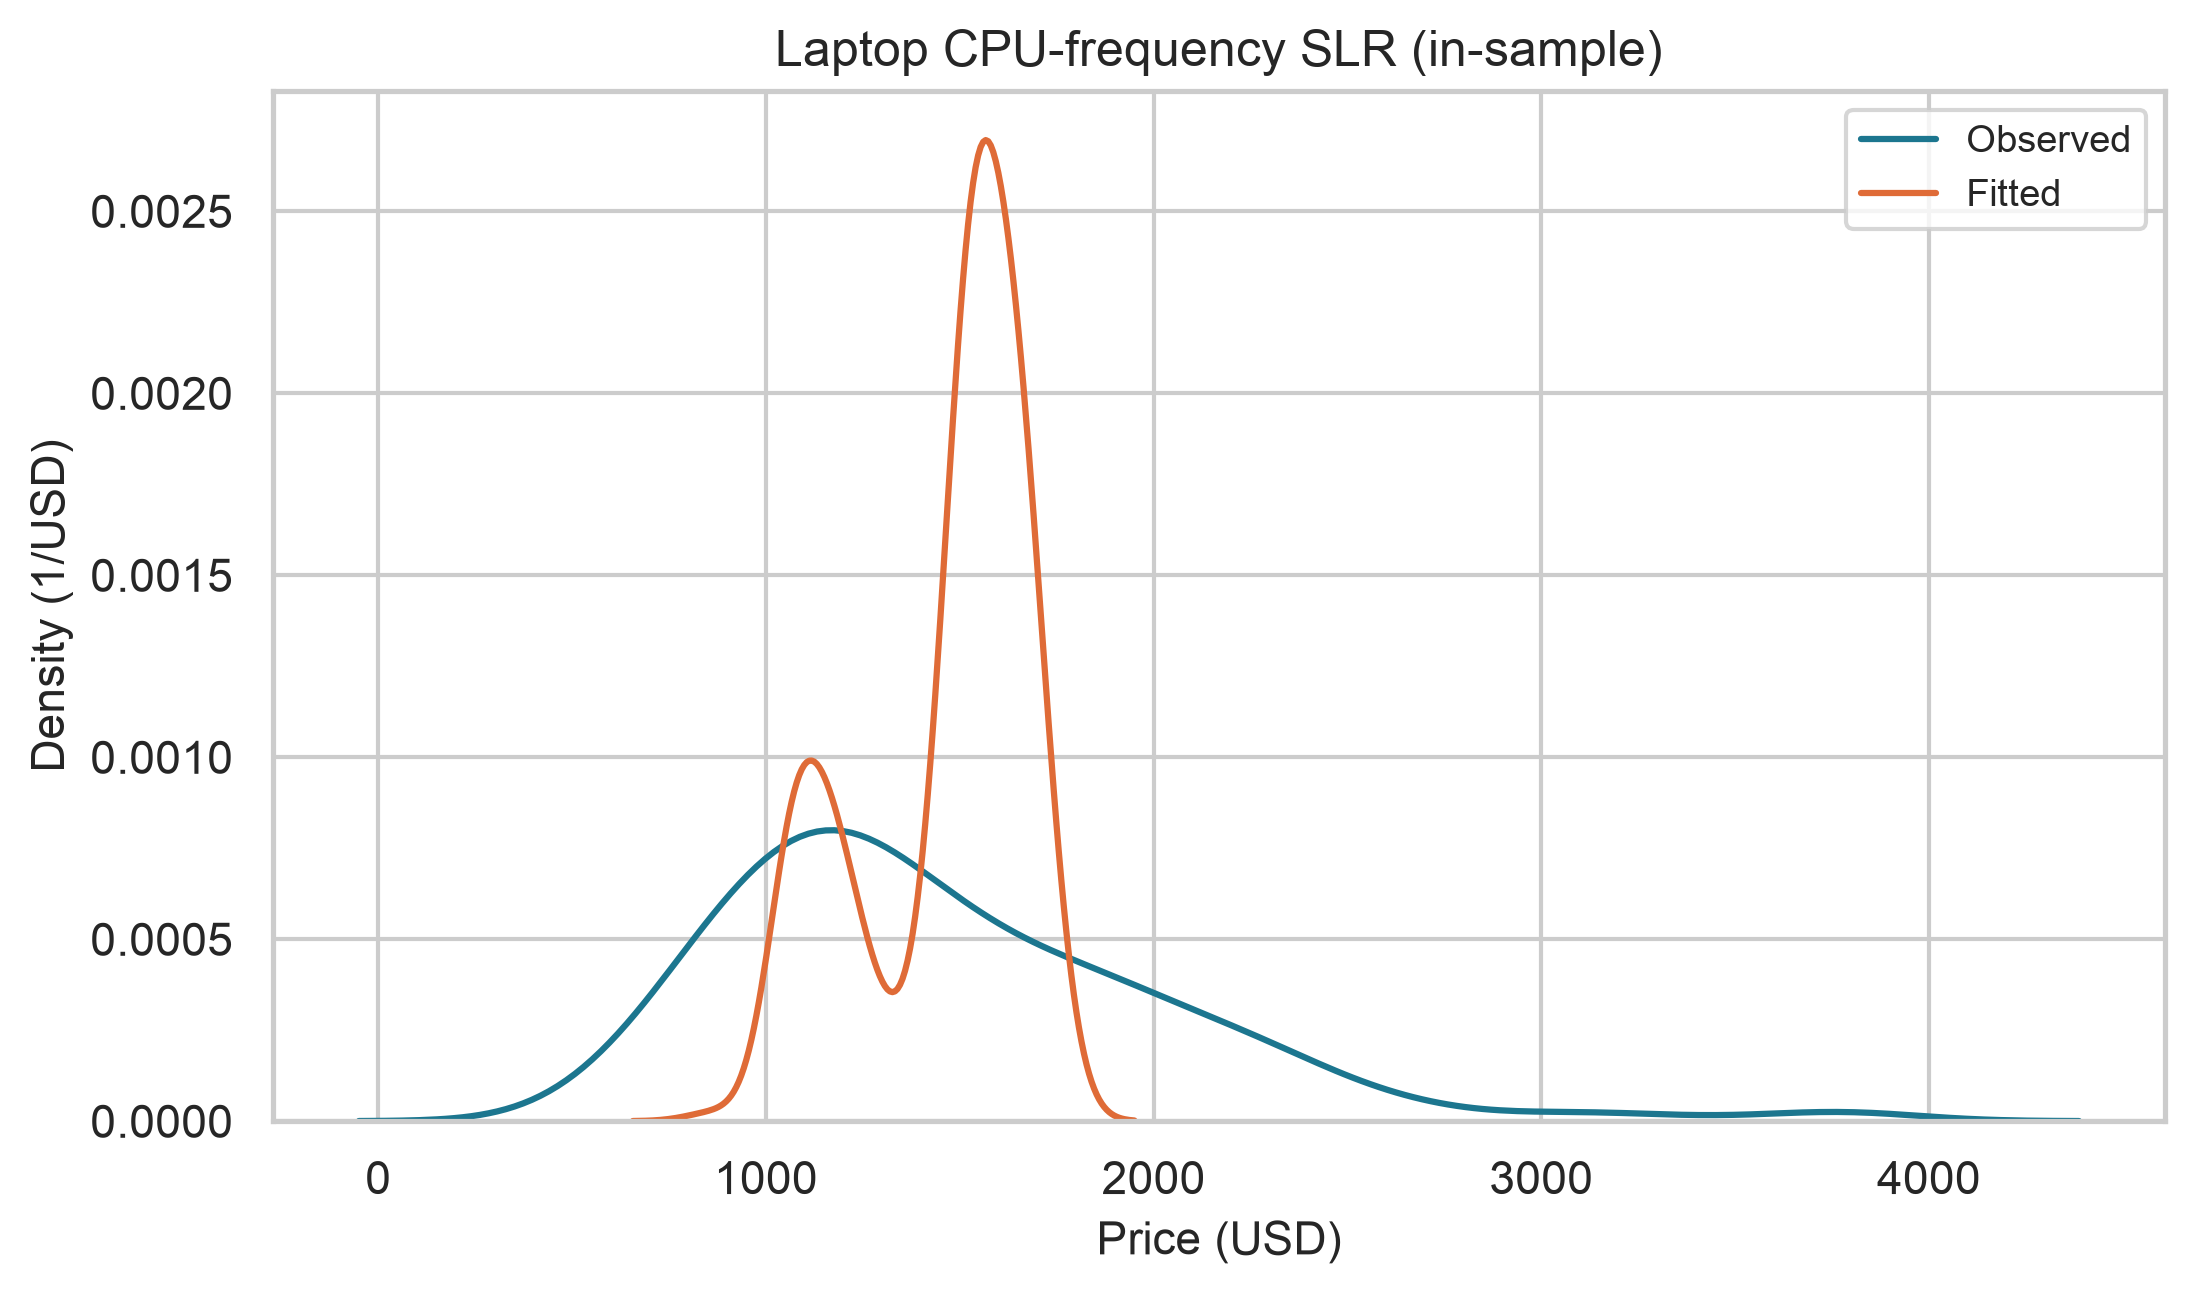

In [9]:
density_plot(Y,Yhat,'Laptop CPU-frequency SLR (in-sample)')

A one-feature line compresses prices into a limited fitted range. Density overlap concerns marginal distributions; it does not measure whether each laptop receives the correct predicted price.

Evaluate the Mean Squared Error and R^2 score values for the model. 


In [10]:
slr_metrics = metrics_row('CPU-frequency SLR',Y,Yhat)
display(pd.DataFrame([slr_metrics]).set_index('Model'))
print(f"Only {slr_metrics['R²']:.1%} of the observed price variance is explained by this fitted line.")

,R²,MSE (USD²)
Model,,
CPU-frequency SLR,0.1344,284583.4406


Only 13.4% of the observed price variance is explained by this fitted line.


# Task 2: Multiple Linear Regression

Use `CPU_frequency`, `RAM_GB`, `Storage_GB_SSD`, `CPU_core`, `OS`, `GPU` and `Category` to create a Multiple Linear Regression model.

These are the required seven predictors. Small p-values do not imply strong effects, and integer category codes are not naturally continuous measurements.

In [11]:
features = ['CPU_frequency','RAM_GB','Storage_GB_SSD','CPU_core','OS','GPU','Category']
Z = df[features]
lm2 = LinearRegression().fit(Z,Y)
Yhat_mlr = lm2.predict(Z)
display(pd.Series(lm2.coef_,index=features,name='Coefficient'))

CPU_frequency     961.2840
RAM_GB             86.8089
Storage_GB_SSD      0.3946
CPU_core           65.6634
OS               -427.4453
GPU                97.8001
Category          191.2955
Name: Coefficient, dtype: float64

Plot the Distribution graph of the predicted values as well as the Actual values


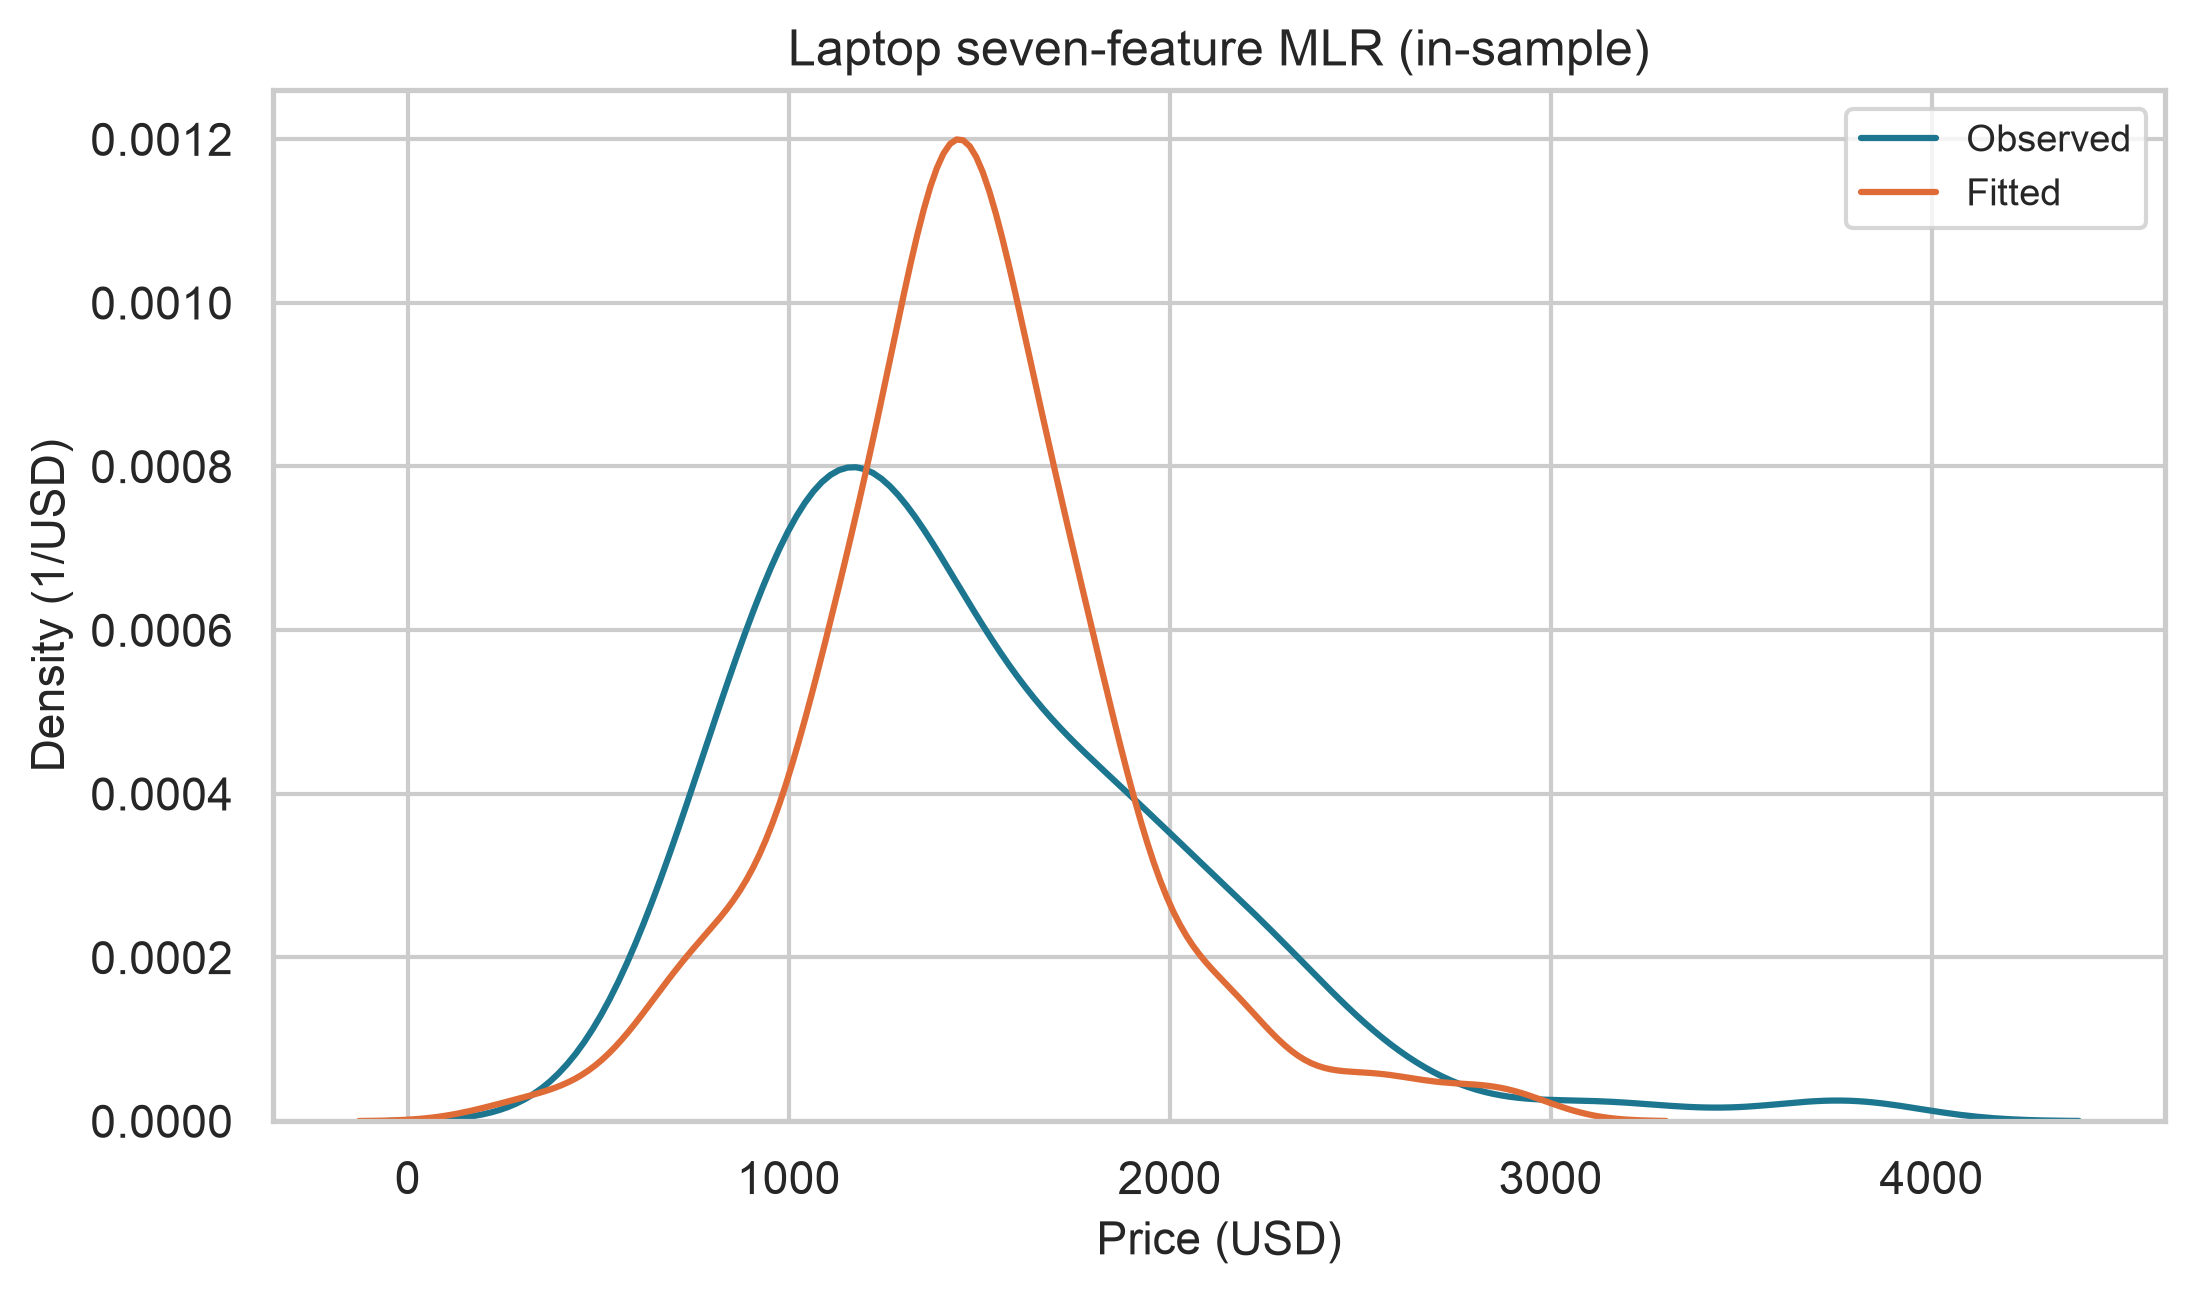

In [12]:
density_plot(Y,Yhat_mlr,'Laptop seven-feature MLR (in-sample)')

Find the R^2 score and the MSE value for this fit. Is this better or worst than the performance of Single Linear Regression?


In [13]:
mlr_metrics = metrics_row('Seven-feature MLR',Y,Yhat_mlr)
display(pd.DataFrame([slr_metrics,mlr_metrics]).set_index('Model'))
print(f"MLR reduces in-sample MSE by {1-mlr_metrics['MSE (USD²)']/slr_metrics['MSE (USD²)']:.1%}; this is a fit improvement, not a validation result.")

,R²,MSE (USD²)
Model,,
CPU-frequency SLR,0.1344,284583.4406
Seven-feature MLR,0.5083,161680.5726


MLR reduces in-sample MSE by 43.2%; this is a fit improvement, not a validation result.


OS, GPU, Category and CPU_core are supplied codes. Their code dictionaries are not verified here, so CPU_core is not interpreted as a physical core count. Using codes numerically follows this exercise but imposes distances and ordering; their coefficients and polynomial interactions should not be given causal or physical interpretations.

# Task 3 - Polynomial Regression
Use the variable "CPU_frequency" to create Polynomial features. Try this for 3 different values of polynomial degrees. Remember that polynomial fits are done using `numpy.polyfit`. 


In [14]:
x = df['CPU_frequency']
y = df['Price']
f1,f3,f5 = [np.polyfit(x,y,degree) for degree in (1,3,5)]
p1,p3,p5 = [np.poly1d(coef) for coef in (f1,f3,f5)]
for p in (p1,p3,p5):
    print(f'Degree {p.order}:')
    print(p)

Degree 1:
 
1485 x + 253.7
Degree 3:
           3             2
3.409e+04 x - 6.574e+04 x + 4.129e+04 x - 7238
Degree 5:
           5            4             3             2
1.357e+06 x - 4.72e+06 x + 6.458e+06 x - 4.336e+06 x + 1.425e+06 x - 1.818e+05


Plot the regression output against the actual data points to note how the data fits in each case. To plot the polynomial response over the actual data points, you have the function shown below.


In [15]:
def PlotPolly(model, independent_variable, dependent_variable, Name):
    x_new = np.linspace(independent_variable.min(), independent_variable.max(),100)
    fig, ax = plt.subplots()
    ax.scatter(independent_variable, dependent_variable,s=22,alpha=.55,label='Observed')
    ax.plot(x_new,model(x_new),color='#df6b37',label=f'Degree {model.order} fit')
    ax.set(title=f'Laptop CPU-frequency polynomial: degree {model.order}',
           xlabel=Name,ylabel='Price (USD)')
    ax.legend()
    plt.show()

Call this function for the 3 models created and get the required graphs.


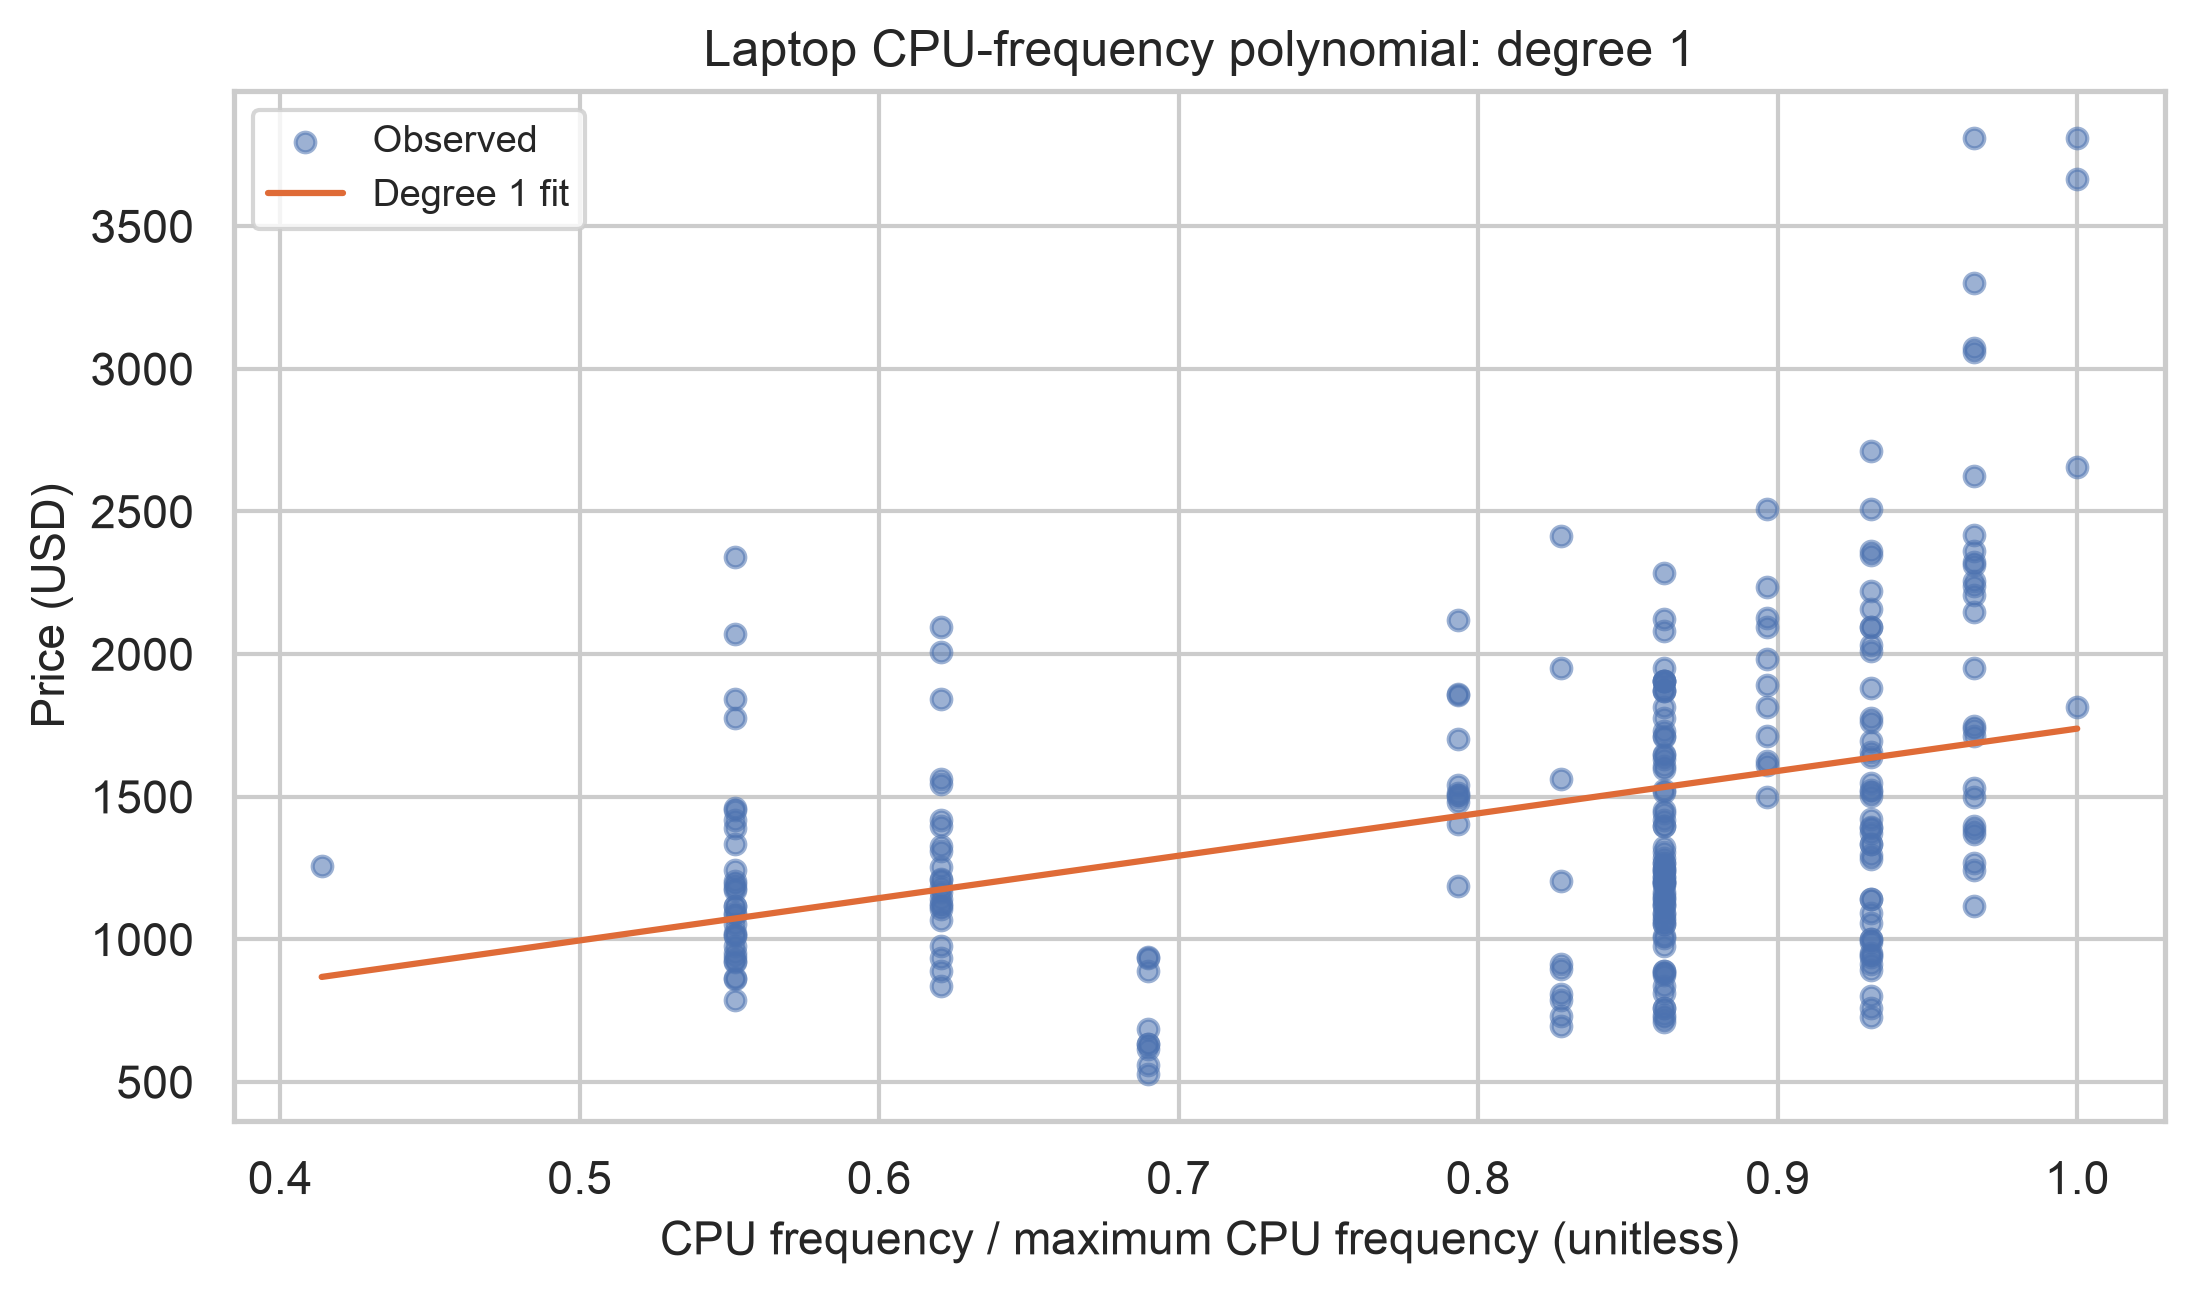

In [16]:
PlotPolly(p1,x,y,'CPU frequency / maximum CPU frequency (unitless)')

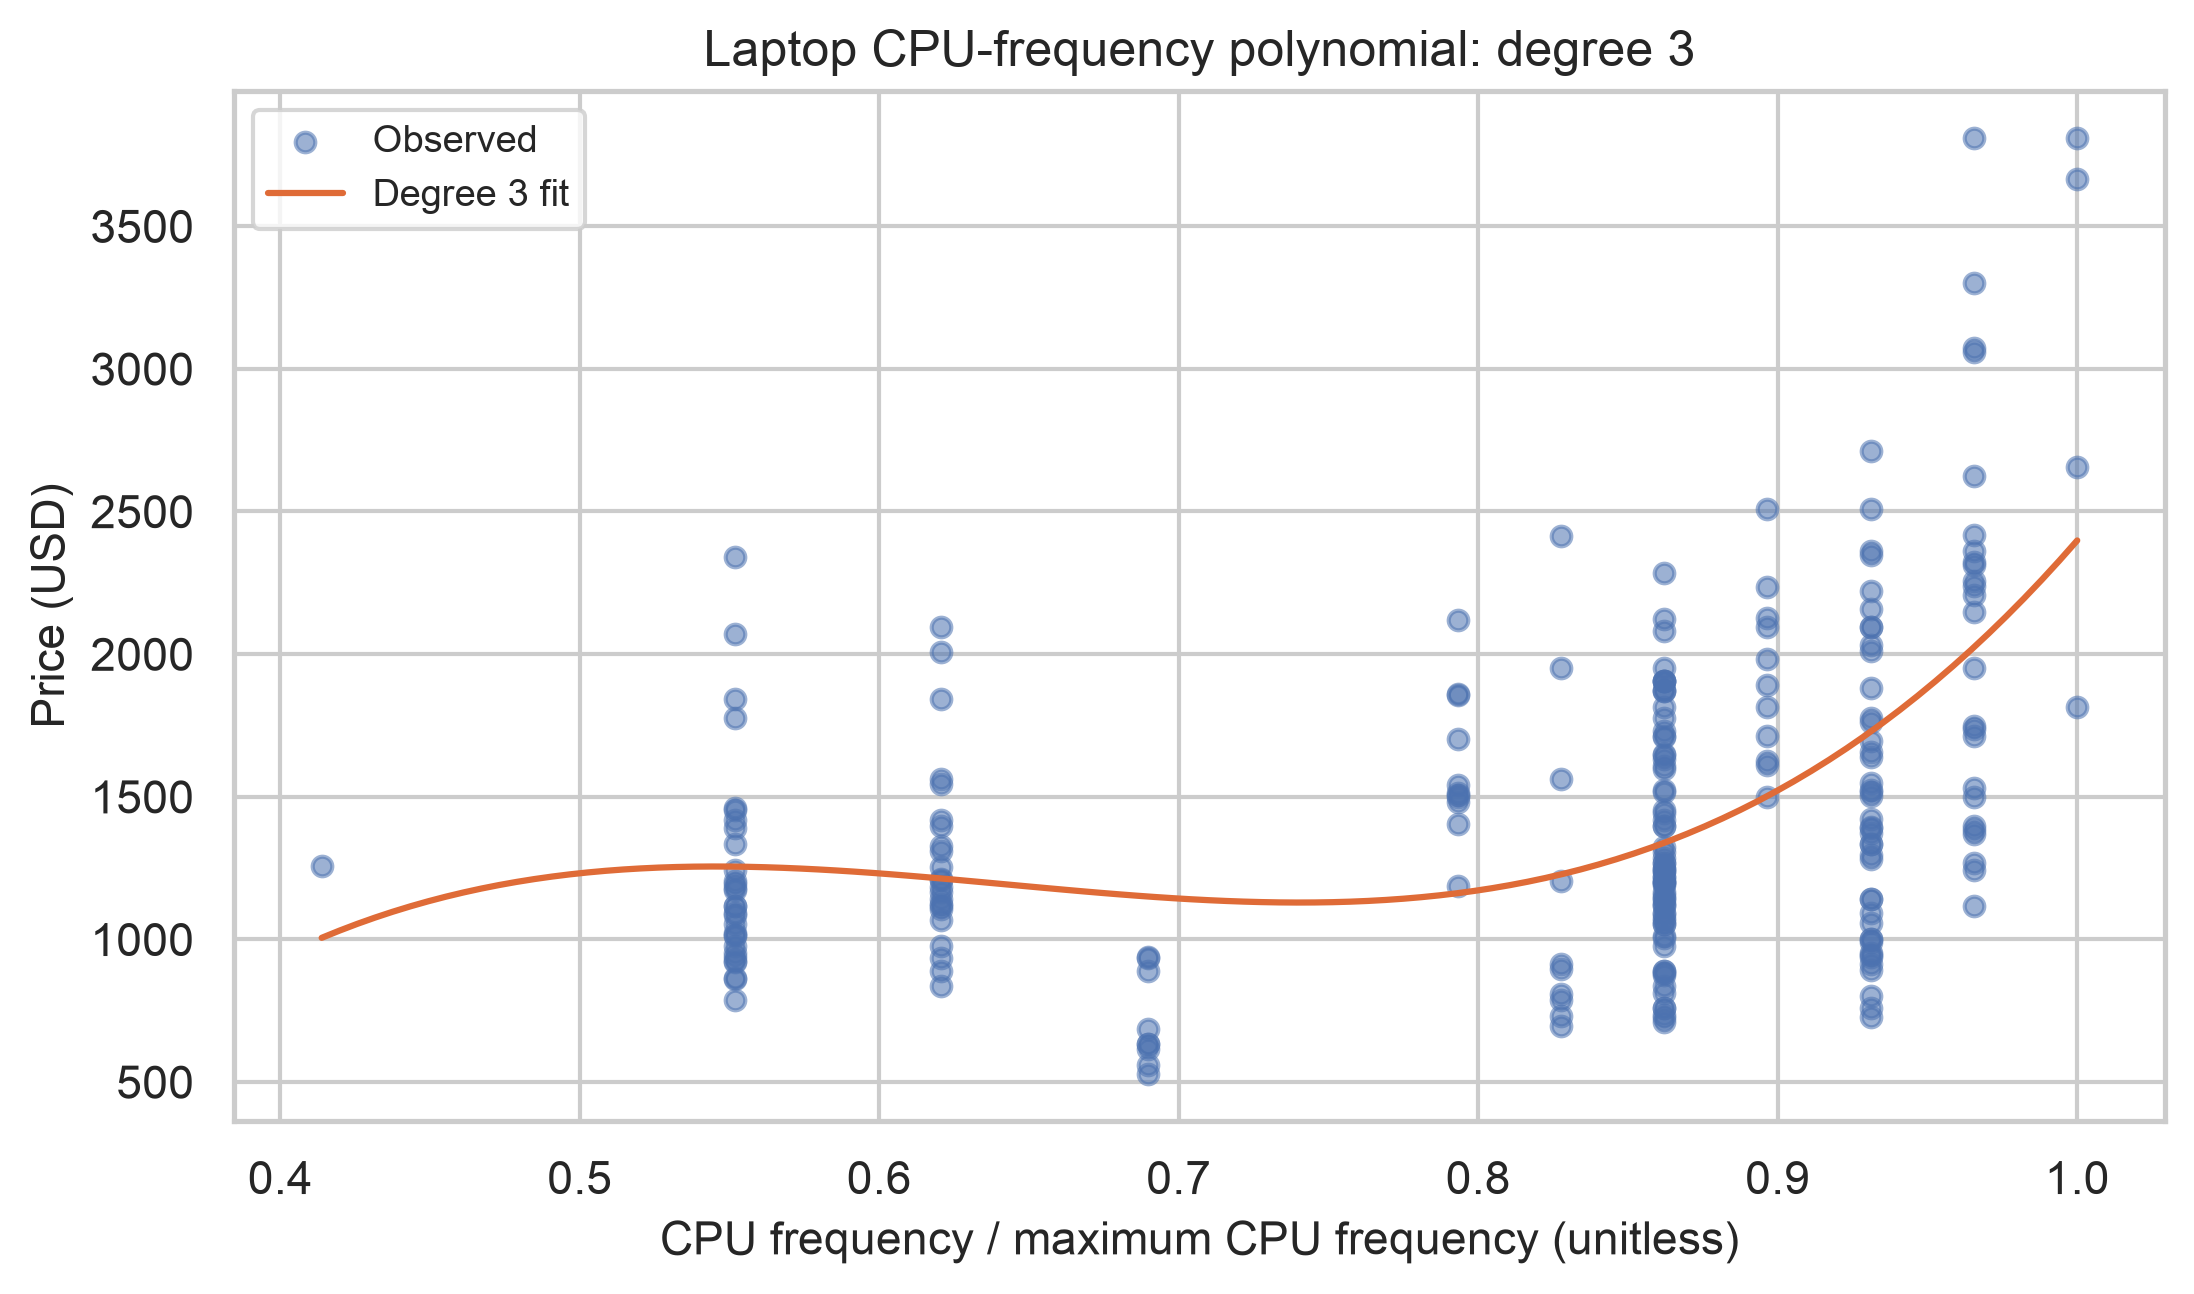

In [17]:
PlotPolly(p3,x,y,'CPU frequency / maximum CPU frequency (unitless)')

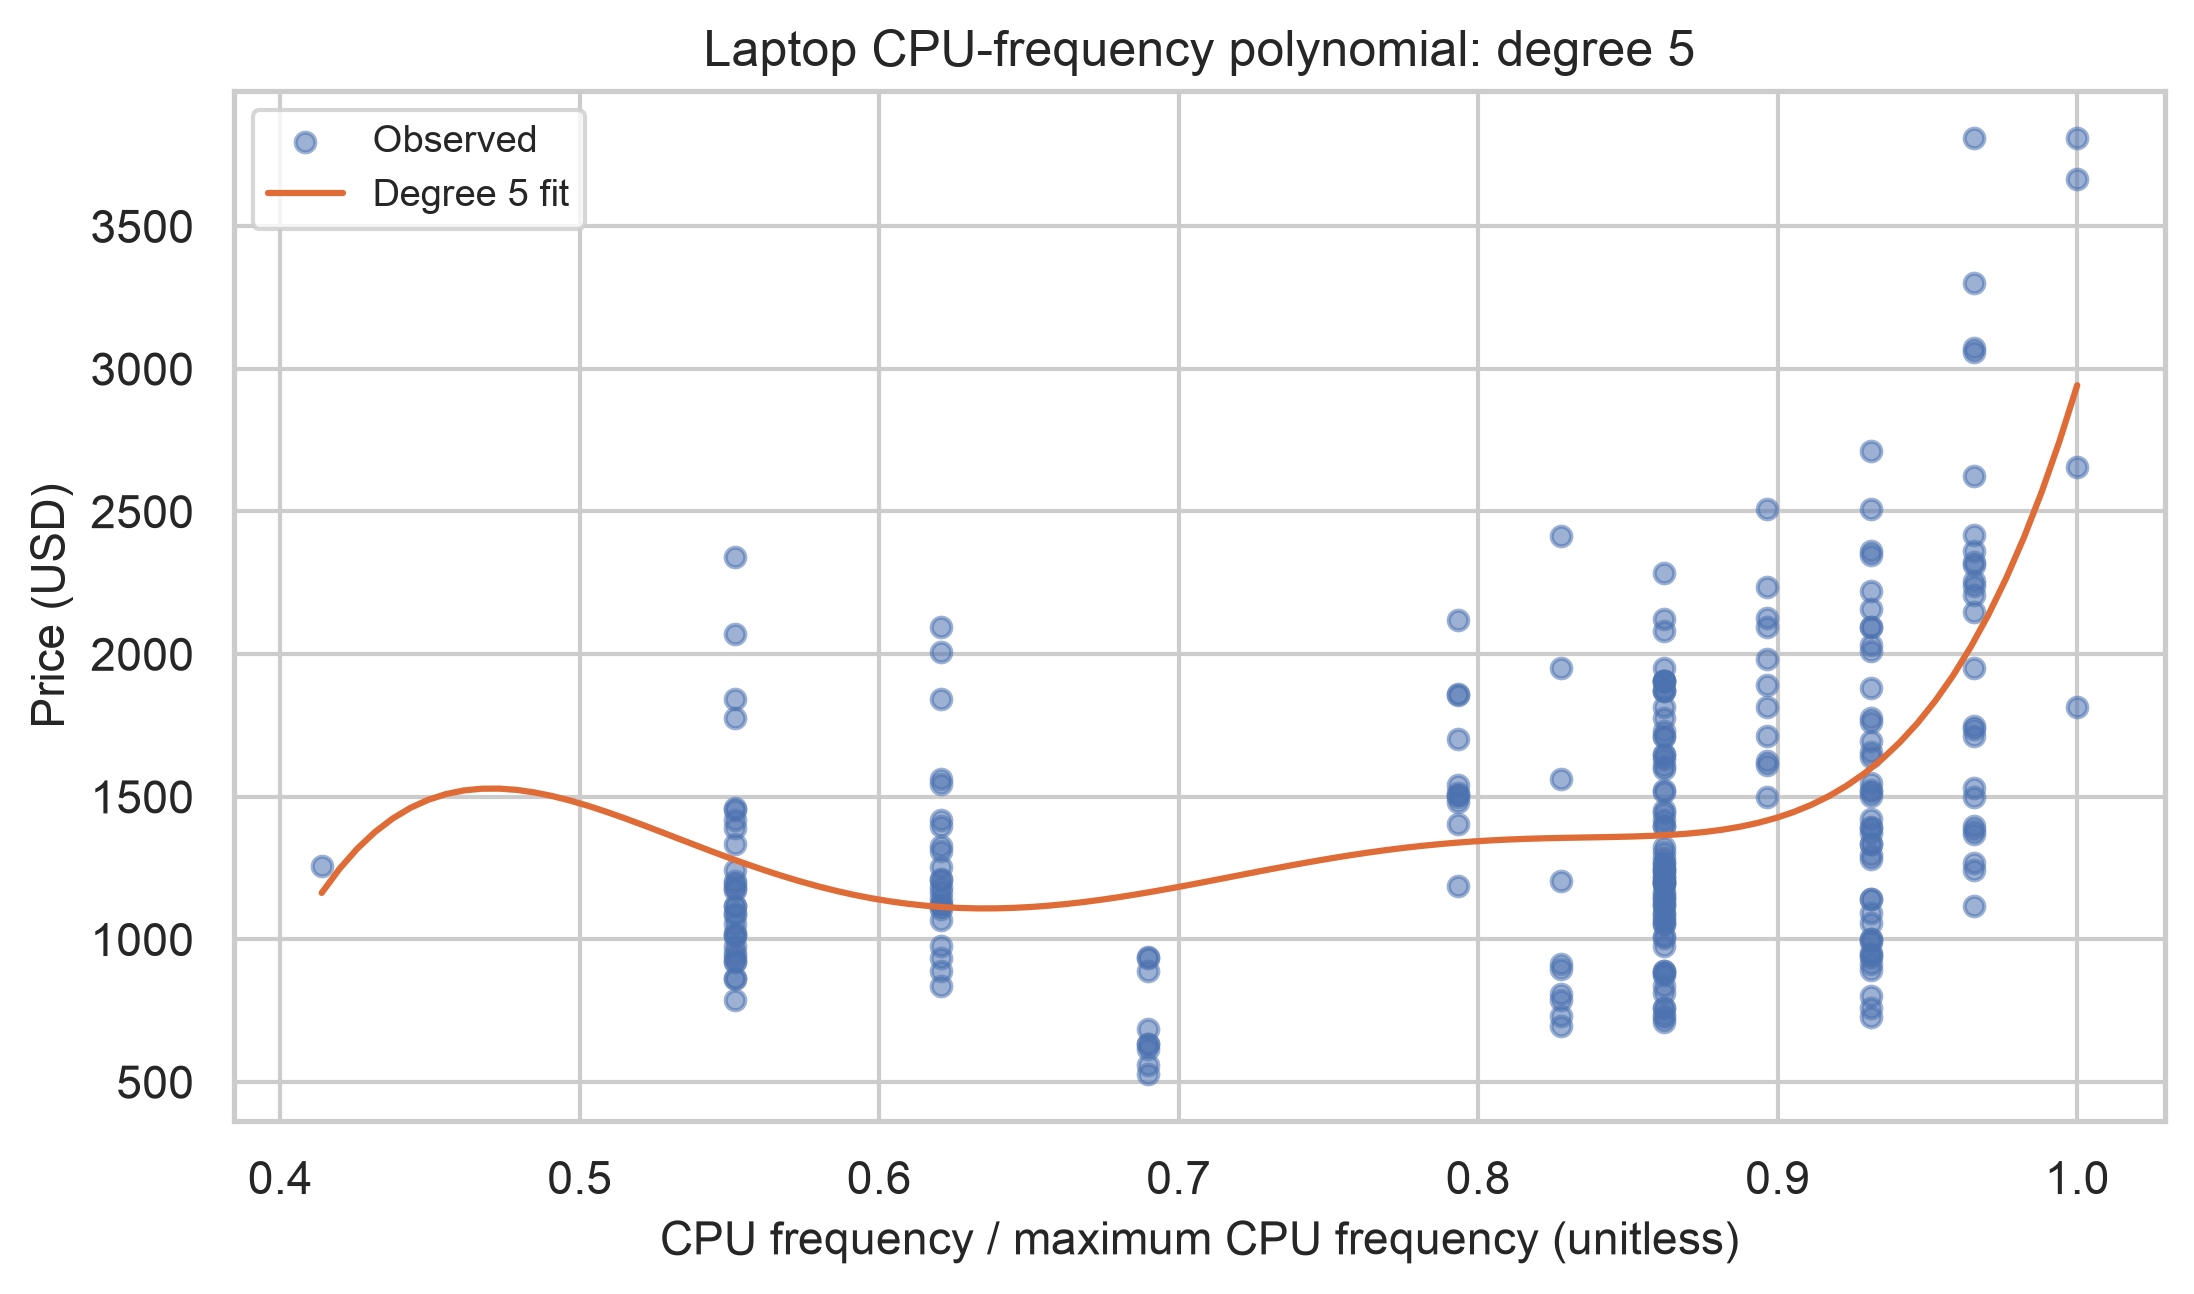

In [18]:
PlotPolly(p5,x,y,'CPU frequency / maximum CPU frequency (unitless)')

Also, calculate the R^2 and MSE values for these fits. For polynomial functions, the function sklearn.metrics.r2_score will be used to calculate R^2 values.


In [19]:
poly_metrics = [metrics_row(f'CPU-frequency degree {p.order}',y,p(x)) for p in (p1,p3,p5)]
display(pd.DataFrame(poly_metrics).set_index('Model'))
print('The single predictor leaves substantial price variation unexplained even after adding curvature.')

,R²,MSE (USD²)
Model,,
CPU-frequency degree 1,0.1344,284583.4406
CPU-frequency degree 3,0.2669,241024.8630
CPU-frequency degree 5,0.3031,229137.2955


The single predictor leaves substantial price variation unexplained even after adding curvature.


# Task 4 - Pipeline
Create a pipeline that performs parameter scaling, Polynomial Feature generation and Linear regression. Use the set of multiple features as before to create this pipeline. 


In [20]:
Input = [('scale',StandardScaler()),('polynomial',PolynomialFeatures(degree=2,include_bias=False)),('model',LinearRegression())]
pipe = Pipeline(Input)
pipe.fit(Z,Y)
Yhat_pipe = pipe.predict(Z)
print('Input features:',Z.shape[1])
print('Polynomial features:',pipe.named_steps['polynomial'].n_output_features_)
print('First five fitted prices (USD):',np.round(Yhat_pipe[:5],2))

Input features: 7
Polynomial features: 35
First five fitted prices (USD): [1484.18  778.37 1267.81 1009.7  1505.21]


Evaluate the MSE and R^2 values for the this predicted output.


In [21]:
pipe_metrics = metrics_row('Scaled seven-feature quadratic pipeline',Y,Yhat_pipe)
display(pd.DataFrame([pipe_metrics]).set_index('Model'))

,R²,MSE (USD²)
Model,,
Scaled seven-feature quadratic pipeline,0.6332,120595.8613


The comparison below reports measured in-sample fit. Adding variables and polynomial terms expands model flexibility; it does not automatically improve performance on future laptops.

In [22]:
comparison = pd.DataFrame([slr_metrics,mlr_metrics]+poly_metrics+[pipe_metrics]).set_index('Model')
display(comparison)
print(f"The quadratic pipeline achieves in-sample R²={pipe_metrics['R²']:.3f}, compared with {mlr_metrics['R²']:.3f} for MLR.")
print('All models were fitted and scored on the same 238 records. Holdout or cross-validation is needed to assess generalization.')

,R²,MSE (USD²)
Model,,
CPU-frequency SLR,0.1344,284583.4406
Seven-feature MLR,0.5083,161680.5726
CPU-frequency degree 1,0.1344,284583.4406
CPU-frequency degree 3,0.2669,241024.8630
CPU-frequency degree 5,0.3031,229137.2955
Scaled seven-feature quadratic pipeline,0.6332,120595.8613


The quadratic pipeline achieves in-sample R²=0.633, compared with 0.508 for MLR.
All models were fitted and scored on the same 238 records. Holdout or cross-validation is needed to assess generalization.


# Congratulations! You have completed the lab


## Authors


[Abhishek Gagneja](https://www.coursera.org/instructor/~129186572)

[Vicky Kuo](https://author.skills.network/instructors/vicky_kuo)


### Copyright ©IBM Corporation. All rights reserved.


<!--## Change Log


<!--|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2023-09-16|0.1|Abhishek Gagneja|Initial Version Created|
|2023-09-19|0.2|Vicky Kuo|Reviewed and Revised|--!>
